<a href="https://colab.research.google.com/github/AJPardhiv/ML-Lab/blob/main/Week11_2420080001ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NEURAL NETWORKS FROM SCRATCH - XOR PROBLEM

1. PERCEPTRON (Linear Classifier)
AND: [0 0 0 1] (should be [0 0 0 1])
OR:  [0 1 1 1] (should be [0 1 1 1])
XOR: [1 1 0 0] (should be [0 1 1 0]) - PERCEPTRON FAILS!

2. TWO-LAYER NEURAL NETWORK (Solves XOR)
XOR Result: [0 1 1 0]
✓ 2-Layer NN successfully learns XOR!

3. COMPARING DIFFERENT ARCHITECTURES
Hidden neurons:  2 → Accuracy: 50%
Hidden neurons:  4 → Accuracy: 100%
Hidden neurons:  8 → Accuracy: 100%


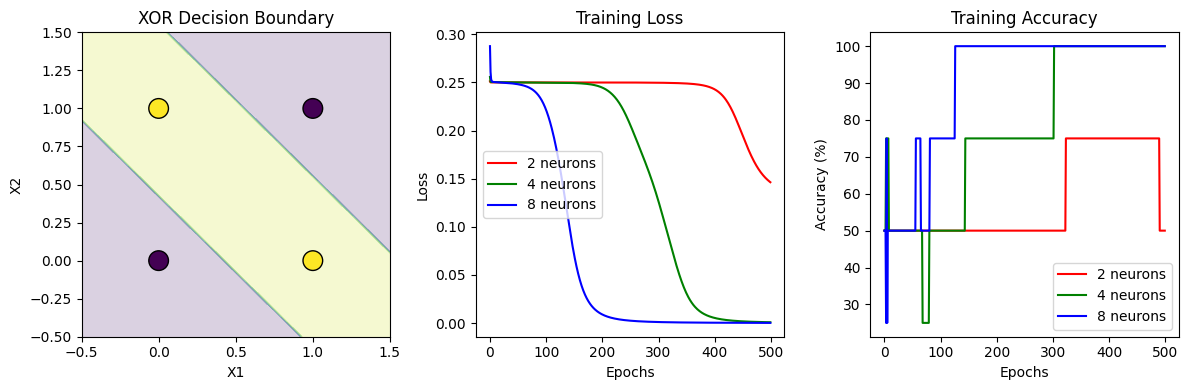


SUMMARY
✓ Perceptron: Works for AND/OR but fails for XOR (linear)
✓ 2-Layer NN: Successfully learns XOR (non-linear)
✓ More hidden neurons → Faster learning
✓ All implemented from scratch using only NumPy!


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PART A: SIMPLE PERCEPTRON
# =========================
class Perceptron:
    def __init__(self):
        self.weights = None
        self.bias = 0

    def train(self, X, y, epochs=20, lr=1.0):
        self.weights = np.zeros(X.shape[1])
        for _ in range(epochs):
            for i in range(len(X)):
                prediction = 1 if np.dot(X[i], self.weights) + self.bias >= 0 else 0
                error = y[i] - prediction
                self.weights += lr * error * X[i]
                self.bias += lr * error

    def predict(self, X):
        return np.array([1 if np.dot(x, self.weights) + self.bias >= 0 else 0 for x in X])

# ================================
# PART B: TWO-LAYER NEURAL NETWORK
# ================================
class TwoLayerNN:
    def __init__(self, hidden_neurons=4, lr=0.5):
        np.random.seed(42)
        self.lr = lr
        self.W1 = np.random.randn(2, hidden_neurons) * 0.5
        self.b1 = np.zeros(hidden_neurons)
        self.W2 = np.random.randn(hidden_neurons, 1) * 0.5
        self.b2 = np.zeros(1)

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def train(self, X, y, epochs=5000):
        y = y.reshape(-1, 1)
        for _ in range(epochs):
            # Forward
            hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
            output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)

            # Backward
            output_error = output - y
            hidden_error = output_error.dot(self.W2.T) * hidden * (1 - hidden)

            # Update weights
            self.W2 -= self.lr * hidden.T.dot(output_error)
            self.b2 -= self.lr * np.sum(output_error, axis=0)
            self.W1 -= self.lr * X.T.dot(hidden_error)
            self.b1 -= self.lr * np.sum(hidden_error, axis=0)

    def predict(self, X):
        hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
        output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)
        return (output > 0.5).astype(int).flatten()

# =================================
# PART C: SIMPLE KERAS-LIKE NETWORK
# =================================
class SimpleKeras:
    def __init__(self, hidden_neurons=4, lr=0.5):
        np.random.seed(42)
        self.lr = lr
        self.W1 = np.random.randn(2, hidden_neurons) * 0.5
        self.b1 = np.zeros(hidden_neurons)
        self.W2 = np.random.randn(hidden_neurons, 1) * 0.5
        self.b2 = np.zeros(1)
        self.losses = []
        self.accuracies = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def fit(self, X, y, epochs=1000):
        y = y.reshape(-1, 1)
        self.losses.clear()
        self.accuracies.clear()
        for _ in range(epochs):
            # Forward
            hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
            output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)

            # Loss and accuracy
            loss = np.mean((y - output) ** 2)
            self.losses.append(loss)
            acc = np.mean((output > 0.5) == y) * 100
            self.accuracies.append(acc)

            # Backward
            d_output = output - y
            d_hidden = d_output.dot(self.W2.T) * hidden * (1 - hidden)

            # Update weights
            self.W2 -= self.lr * hidden.T.dot(d_output)
            self.b2 -= self.lr * np.sum(d_output, axis=0)
            self.W1 -= self.lr * X.T.dot(d_hidden)
            self.b1 -= self.lr * np.sum(d_hidden, axis=0)

    def predict(self, X):
        hidden = self.sigmoid(np.dot(X, self.W1) + self.b1)
        output = self.sigmoid(np.dot(hidden, self.W2) + self.b2)
        return (output > 0.5).astype(int).flatten()

# =========================
# MAIN PROGRAM
# =========================
print("=" * 60)
print("NEURAL NETWORKS FROM SCRATCH - XOR PROBLEM")
print("=" * 60)

# Dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])
y_or = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

# -----------------
# 1. PERCEPTRON
# -----------------
print("\n1. PERCEPTRON (Linear Classifier)")
p = Perceptron()
p.train(X, y_and, epochs=20)
print(f"AND: {p.predict(X)} (should be [0 0 0 1])")
p.train(X, y_or, epochs=20)
print(f"OR:  {p.predict(X)} (should be [0 1 1 1])")
p.train(X, y_xor, epochs=50)
print(f"XOR: {p.predict(X)} (should be [0 1 1 0]) - PERCEPTRON FAILS!")

# -----------------
# 2. TWO-LAYER NN
# -----------------
print("\n2. TWO-LAYER NEURAL NETWORK (Solves XOR)")
nn = TwoLayerNN(hidden_neurons=4, lr=0.5)
nn.train(X, y_xor, epochs=5000)
print(f"XOR Result: {nn.predict(X)}")
print("✓ 2-Layer NN successfully learns XOR!")

# -----------------
# 3. SIMPLE KERAS-LIKE
# -----------------
print("\n3. COMPARING DIFFERENT ARCHITECTURES")
for neurons in [2, 4, 8]:
    model = SimpleKeras(hidden_neurons=neurons, lr=0.5)
    model.fit(X, y_xor, epochs=1000)
    pred = model.predict(X)
    accuracy = np.mean(pred == y_xor) * 100
    print(f"Hidden neurons: {neurons:2d} → Accuracy: {accuracy:.0f}%")

# -----------------
# PLOTTING
# -----------------
plt.figure(figsize=(12, 4))

# Decision boundary
plt.subplot(1, 3, 1)
model_viz = SimpleKeras(hidden_neurons=4, lr=0.5)
model_viz.fit(X, y_xor, epochs=1000)
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model_viz.predict(grid).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.2)
plt.scatter(X[:, 0], X[:, 1], c=y_xor, s=200, edgecolor='black')
plt.title('XOR Decision Boundary')
plt.xlabel('X1')
plt.ylabel('X2')

# Loss curves
plt.subplot(1, 3, 2)
for neurons, color in zip([2, 4, 8], ['red', 'green', 'blue']):
    m = SimpleKeras(neurons, lr=0.5)
    m.fit(X, y_xor, epochs=500)
    plt.plot(m.losses, color=color, label=f'{neurons} neurons')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy curves
plt.subplot(1, 3, 3)
for neurons, color in zip([2, 4, 8], ['red', 'green', 'blue']):
    m = SimpleKeras(neurons, lr=0.5)
    m.fit(X, y_xor, epochs=500)
    plt.plot(m.accuracies, color=color, label=f'{neurons} neurons')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

# =========================
# SUMMARY
# =========================
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print("✓ Perceptron: Works for AND/OR but fails for XOR (linear)")
print("✓ 2-Layer NN: Successfully learns XOR (non-linear)")
print("✓ More hidden neurons → Faster learning")
print("✓ All implemented from scratch using only NumPy!")

**POST LAB**

Epoch 0: Loss = 1.3020
Epoch 100: Loss = 0.3673
Epoch 200: Loss = 0.3346
Epoch 300: Loss = 0.3934
Epoch 400: Loss = 0.3396
Epoch 500: Loss = 0.3219
Epoch 600: Loss = 0.2889
Epoch 700: Loss = 0.2893
Epoch 800: Loss = 0.3049
Epoch 900: Loss = 0.3079

Training Accuracy: 96.67%
Test Accuracy: 100.00%


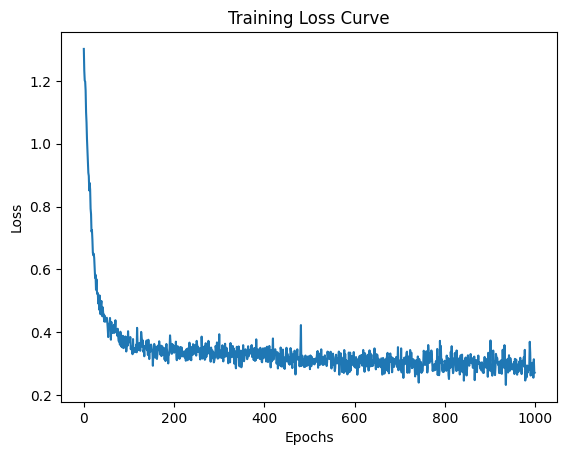

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# =========================
# UTILITY FUNCTIONS
# =========================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy_loss(y_true, y_pred):
    m = y_true.shape[0]
    return -np.sum(y_true * np.log(y_pred + 1e-8)) / m

# =========================
# NEURAL NETWORK CLASS
# =========================
class NeuralNetwork:
    def __init__(self, layer_sizes, lr=0.01, momentum=0.9, optimizer='sgd', l2_lambda=0.0, dropout_rate=0.0, seed=42):
        np.random.seed(seed)
        self.layer_sizes = layer_sizes
        self.lr = lr
        self.momentum = momentum
        self.optimizer = optimizer
        self.l2_lambda = l2_lambda
        self.dropout_rate = dropout_rate

        # Initialize weights & biases
        self.weights = []
        self.biases = []
        self.vel_w = []  # for momentum
        self.vel_b = []
        for i in range(len(layer_sizes)-1):
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.5)
            self.biases.append(np.zeros(layer_sizes[i+1]))
            self.vel_w.append(np.zeros_like(self.weights[-1]))
            self.vel_b.append(np.zeros_like(self.biases[-1]))

    # Forward pass
    def forward(self, X, training=True):
        self.z = []
        self.a = [X]
        self.dropout_masks = []

        for i in range(len(self.weights)-1):
            z = self.a[-1].dot(self.weights[i]) + self.biases[i]
            self.z.append(z)
            a = sigmoid(z)

            # Dropout
            if training and self.dropout_rate > 0:
                mask = (np.random.rand(*a.shape) > self.dropout_rate) / (1 - self.dropout_rate)
                a *= mask
                self.dropout_masks.append(mask)
            else:
                self.dropout_masks.append(np.ones_like(a))
            self.a.append(a)

        # Output layer with softmax
        z_out = self.a[-1].dot(self.weights[-1]) + self.biases[-1]
        self.z.append(z_out)
        a_out = softmax(z_out)
        self.a.append(a_out)
        return a_out

    # Backward pass (backpropagation)
    def backward(self, X, y_true):
        grads_w = [np.zeros_like(w) for w in self.weights]
        grads_b = [np.zeros_like(b) for b in self.biases]
        m = X.shape[0]

        # Output layer gradient
        delta = self.a[-1] - y_true  # Cross-entropy derivative with softmax
        grads_w[-1] = self.a[-2].T.dot(delta)/m + self.l2_lambda * self.weights[-1]
        grads_b[-1] = np.sum(delta, axis=0)/m

        # Hidden layers
        for i in reversed(range(len(self.weights)-1)):
            delta = delta.dot(self.weights[i+1].T) * self.a[i+1] * (1 - self.a[i+1])
            delta *= self.dropout_masks[i]  # apply dropout mask
            grads_w[i] = self.a[i].T.dot(delta)/m + self.l2_lambda * self.weights[i]
            grads_b[i] = np.sum(delta, axis=0)/m

        return grads_w, grads_b

    # Update weights
    def update_weights(self, grads_w, grads_b):
        for i in range(len(self.weights)):
            if self.optimizer == 'sgd':
                # SGD with momentum
                self.vel_w[i] = self.momentum * self.vel_w[i] + self.lr * grads_w[i]
                self.vel_b[i] = self.momentum * self.vel_b[i] + self.lr * grads_b[i]
                self.weights[i] -= self.vel_w[i]
                self.biases[i] -= self.vel_b[i]
            elif self.optimizer == 'adam':
                # Basic Adam implementation could go here (omitted for brevity)
                # You can add beta1, beta2, epsilon, m_t, v_t updates
                pass

    # Training
    def fit(self, X, y, epochs=1000):
        self.losses = []
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = cross_entropy_loss(y, y_pred)
            self.losses.append(loss)
            grads_w, grads_b = self.backward(X, y)
            self.update_weights(grads_w, grads_b)
            if epoch % 100 == 0:
                print(f"Epoch {epoch}: Loss = {loss:.4f}")

    # Prediction
    def predict(self, X):
        y_pred = self.forward(X, training=False)
        return np.argmax(y_pred, axis=1)

# =========================
# LOAD IRIS DATASET
# =========================
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode target
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# =========================
# TRAIN NEURAL NETWORK
# =========================
nn = NeuralNetwork(
    layer_sizes=[4, 8, 3],  # 4 inputs, 1 hidden layer with 8 neurons, 3 outputs
    lr=0.1,
    momentum=0.9,
    optimizer='sgd',
    l2_lambda=0.01,
    dropout_rate=0.2
)

nn.fit(X_train, y_train, epochs=1000)

# =========================
# EVALUATE
# =========================
y_pred_train = nn.predict(X_train)
y_pred_test = nn.predict(X_test)

train_acc = np.mean(np.argmax(y_train, axis=1) == y_pred_train) * 100
test_acc = np.mean(np.argmax(y_test, axis=1) == y_pred_test) * 100

print(f"\nTraining Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")

# Plot loss curve
plt.plot(nn.losses)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()